In [8]:
%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import lightning as L
from torchvision.models import resnet50, ResNet50_Weights
import torchmetrics
from lightning.pytorch.loggers import WandbLogger
import wandb
from dotenv import load_dotenv
import torch.nn.functional as F
from tqdm.notebook import tqdm
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

PROJECT_ROOT = Path('/work')
SCRIPTS_ROOT = PROJECT_ROOT / 'scripts'

for p in (PROJECT_ROOT, SCRIPTS_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from classification_pipeline import (
    load_or_download_classification_dataset,
    ClassificationDownloadConfig,
    build_multiclass_classification_records_from_masks,
    split_grouped_records,
    ToothCropDataset,
    build_classification_resize_pipeline
)

from classification_pipeline import ToothClassificationDataModule, LitToothClassifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
class ToothClassificationDataModule(L.LightningDataModule):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.train_ds = None
        self.val_ds = None
        self.test_ds = None

    def setup(self, stage: str | None = None):
        _, coco_data, image_dirs = load_or_download_classification_dataset(
            ClassificationDownloadConfig(api_key=os.getenv('ROBOFLOW_API_KEY')),
            force_download=self.cfg.force_download
        )
        
        all_records, self.label_map = build_multiclass_classification_records_from_masks(
            coco_data, image_dirs, crop_margin=0.08
        )

        caries_idx = self.label_map.get('Caries', 44)
        for rec in all_records:
            rec['label'] = 1 if rec['label'] == caries_idx else 0
        
        self.label_map = {'Healthy': 0, 'Caries': 1}
        
        train_rec, val_rec, test_rec = split_grouped_records(
            all_records, train_size=0.7, val_size=0.15, test_size=0.15
        )

        all_labels = [rec['label'] for rec in all_records]
        count_0, count_1 = all_labels.count(0), all_labels.count(1)
        total = count_0 + count_1
        self.class_weights = torch.tensor([total/(2*count_0), total/(2*count_1)], dtype=torch.float)
        
        resize_pipeline = build_classification_resize_pipeline(self.cfg.image_size)
        self.test_ds = ToothCropDataset(
            test_rec,
            image_size=self.cfg.image_size,
            resize_transform=resize_pipeline,
            output_channels=3
        )

    def test_dataloader(self):
        return torch.utils.data.DataLoader(
            self.test_ds, 
            batch_size=self.cfg.batch_size, 
            num_workers=self.cfg.num_workers,
            pin_memory=torch.cuda.is_available()
        )

class LitToothClassifier(L.LightningModule):
    def __init__(self, cfg, num_classes=2, class_weights=None):
        super().__init__()
        self.cfg = cfg
        self.model = resnet50(weights=ResNet50_Weights.DEFAULT)
        
        for param in self.model.parameters():
            param.requires_grad = False
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        
        self.accuracy = torchmetrics.Accuracy(task="binary")
        self.f1 = torchmetrics.F1Score(task="binary")

    def forward(self, x):
        return self.model(x)

    def test_step(self, batch, batch_idx):
        x, y, _ = batch
        
        logits = self(x)
        
        loss = F.cross_entropy(logits, y, weight=self.class_weights if hasattr(self, 'class_weights') else None)
        
        preds = torch.argmax(logits, dim=1)
        self.accuracy(preds, y)
        self.f1(preds, y)
        
        self.log("test/loss", loss, on_step=False, on_epoch=True)
        self.log("test/acc", self.accuracy, on_step=False, on_epoch=True)
        self.log("test/f1", self.f1, on_step=False, on_epoch=True)
        
        return loss

In [2]:
class EvalConfig:
    image_size: int = 224
    batch_size: int = 32
    num_workers: int = 6
    wandb_project: str = 'tooth-caries-classification'
    wandb_run_id = 'j7lnhn3l'
    force_download: bool = False

cfg = EvalConfig()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [3]:
env_path = Path('/work/.env')
if not env_path.exists():
    raise FileNotFoundError(f'.env file not found at {env_path}')

load_dotenv(env_path, override=True)

wandb_secret = (os.getenv('WANDB_API_KEY') or '').strip().strip('"').strip("'")
if not wandb_secret:
    raise RuntimeError(f'WANDB_API_KEY not found in {env_path}')

if len(wandb_secret) < 20:
    raise RuntimeError(
        f'Invalid WANDB_API_KEY length ({len(wandb_secret)}). '
        'Expected a classic API key or a wandb_v1 access token from https://wandb.ai/authorize.'
    )

# Support both classic API keys and wandb_v1 access tokens.
try:
    os.environ['WANDB_API_KEY'] = wandb_secret
    wandb.login(key=wandb_secret, relogin=True)
except AuthenticationError:
    if wandb_secret.startswith('wandb_v1_'):
        # Compatibility fallback for SDKs that validate only classic key shapes.
        compat_key = wandb_secret.replace('wandb_v1_', '', 1)
        os.environ['WANDB_API_KEY'] = compat_key
        wandb.login(key=compat_key, relogin=True)
    else:
        raise

print('W&B login successful using WANDB_API_KEY from .env')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nagycsd01 (nagycsd01-university-of-budapest-technology-and-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful using WANDB_API_KEY from .env


In [7]:
datamodule = ToothClassificationDataModule(cfg)
datamodule.setup()

checkpoint_path = PROJECT_ROOT / 'output' / 'checkpoints' / 'classification' / 'full_test-v1.ckpt'

wandb_logger = WandbLogger(
    project=cfg.wandb_project,
    id=cfg.wandb_run_id,
    resume='must'
)

model = LitToothClassifier.load_from_checkpoint(
    str(checkpoint_path),
    cfg=cfg,
    num_classes=2,
    class_weights=datamodule.class_weights
)
model.eval()
model.freeze()

tester = L.Trainer(
    accelerator='auto',
    devices=1,
    precision='16-mixed',
    logger=wandb_logger
)
test_results = tester.test(model, datamodule=datamodule)

Osztálysúlyok: tensor([0.5286, 9.2363])
Train samples: 76788
Val samples: 16704
Test samples: 16106


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless 

Osztálysúlyok: tensor([0.5286, 9.2363])
Train samples: 76788
Val samples: 16704
Test samples: 16106


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.8434123992919922     │
│          test/f1          │    0.37512388825416565    │
│         test/loss         │    0.3920859694480896     │
└───────────────────────────┴───────────────────────────┘

Generating predictions on the test set...


Evaluation Progress:   0%|          | 0/504 [00:00<?, ?it/s]

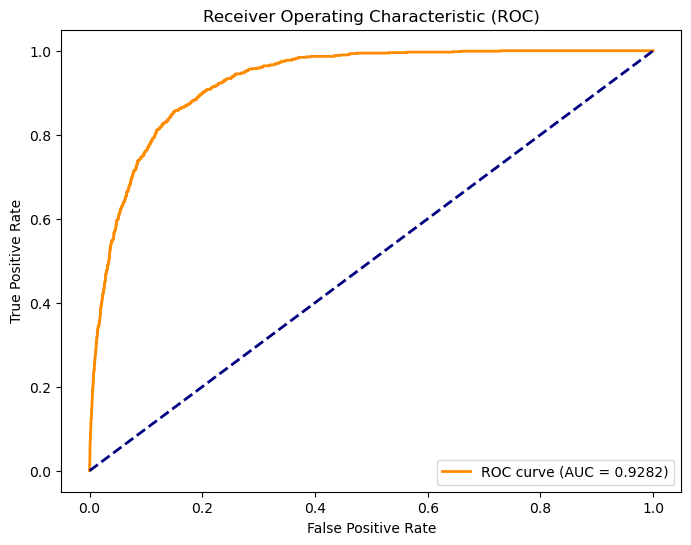

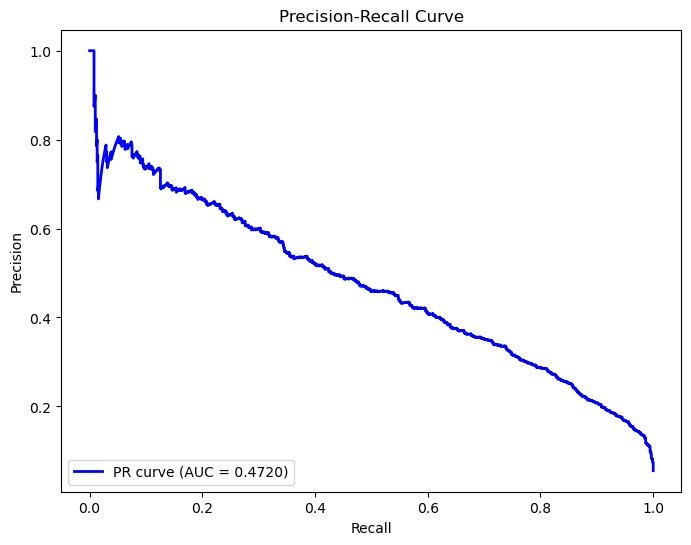

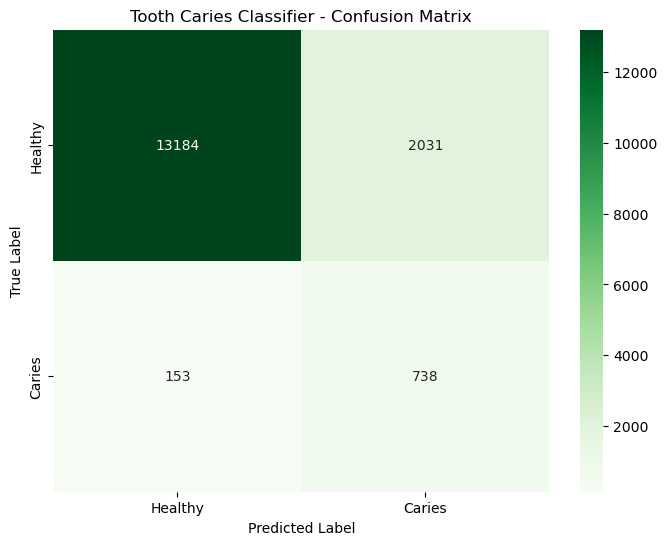


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.87      0.92     15215
      Caries       0.27      0.83      0.40       891

    accuracy                           0.86     16106
   macro avg       0.63      0.85      0.66     16106
weighted avg       0.95      0.86      0.89     16106

Logging evaluation results to W&B...


epoch,▁
test/acc,▁
test/accuracy,▁
test/f1,▁
test/f1_score,▁
test/loss,▁
test/pr_auc,▁
test/precision,▁
test/recall,▁
test/roc_auc,▁
+1,...


Done! Check your W&B dashboard.


In [9]:
all_preds = []
all_labels = []
all_probs = [] 

print("Generating predictions on the test set...")
with torch.no_grad():
    for batch in tqdm(datamodule.test_dataloader(), desc="Evaluation Progress"):
        x, y, _ = batch
        logits = model(x.to(model.device))
        
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
caries_probs = all_probs[:, 1] 

fpr, tpr, _ = roc_curve(all_labels, caries_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")
plt.show()

precision, recall, _ = precision_recall_curve(all_labels, caries_probs)
pr_auc = average_precision_score(all_labels, caries_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig("pr_curve.png")
plt.show()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Healthy', 'Caries'], 
            yticklabels=['Healthy', 'Caries'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tooth Caries Classifier - Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

print("\nClassification Report:")
report = classification_report(all_labels, all_preds, target_names=['Healthy', 'Caries'], output_dict=True)
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Caries']))

if wandb.run is None:
    wandb.init(project=cfg.wandb_project, id=cfg.wandb_run_id, resume='must')

print("Logging evaluation results to W&B...")

wandb.log({
    "test/confusion_matrix_plot": wandb.Image("confusion_matrix.png"),
    "test/roc_curve_plot": wandb.Image("roc_curve.png"),
    "test/pr_curve_plot": wandb.Image("pr_curve.png")
})

wandb.log({
    "test/f1_score": report['Caries']['f1-score'],
    "test/recall": report['Caries']['recall'],
    "test/precision": report['Caries']['precision'],
    "test/accuracy": report['accuracy'],
    "test/roc_auc": roc_auc
    "test/pr_auc": pr_au
})

wandb.log({
    "test/interactive_cm": wandb.plot.confusion_matrix(
        probs=None, y_true=all_labels, preds=all_preds, class_names=['Healthy', 'Caries']
    ),
    "test/interactive_roc": wandb.plot.roc_curve(
        all_labels, all_probs, labels=['Healthy', 'Caries']
    ),
    "test/interactive_pr": wandb.plot.pr_curve(
        all_labels, all_probs, labels=['Healthy', 'Caries']
    )
})

wandb.finish()
print("Done! Check your W&B dashboard.")